In [1]:
import pandas as pd
import numpy as np
!pip install flask

df = pd.read_csv('Train.csv')

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

--- First 5 Rows ---
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                44      

In [2]:

df['Calls_Per_Purchase'] = df['Customer_care_calls'] / (df['Prior_purchases'] + 1)

print("Total Features Now:", len(df.columns))
print(df.columns)

Total Features Now: 13
Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N', 'Calls_Per_Purchase'],
      dtype='object')


In [3]:

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)


--- Missing Values Count ---
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
Calls_Per_Purchase     0
dtype: int64


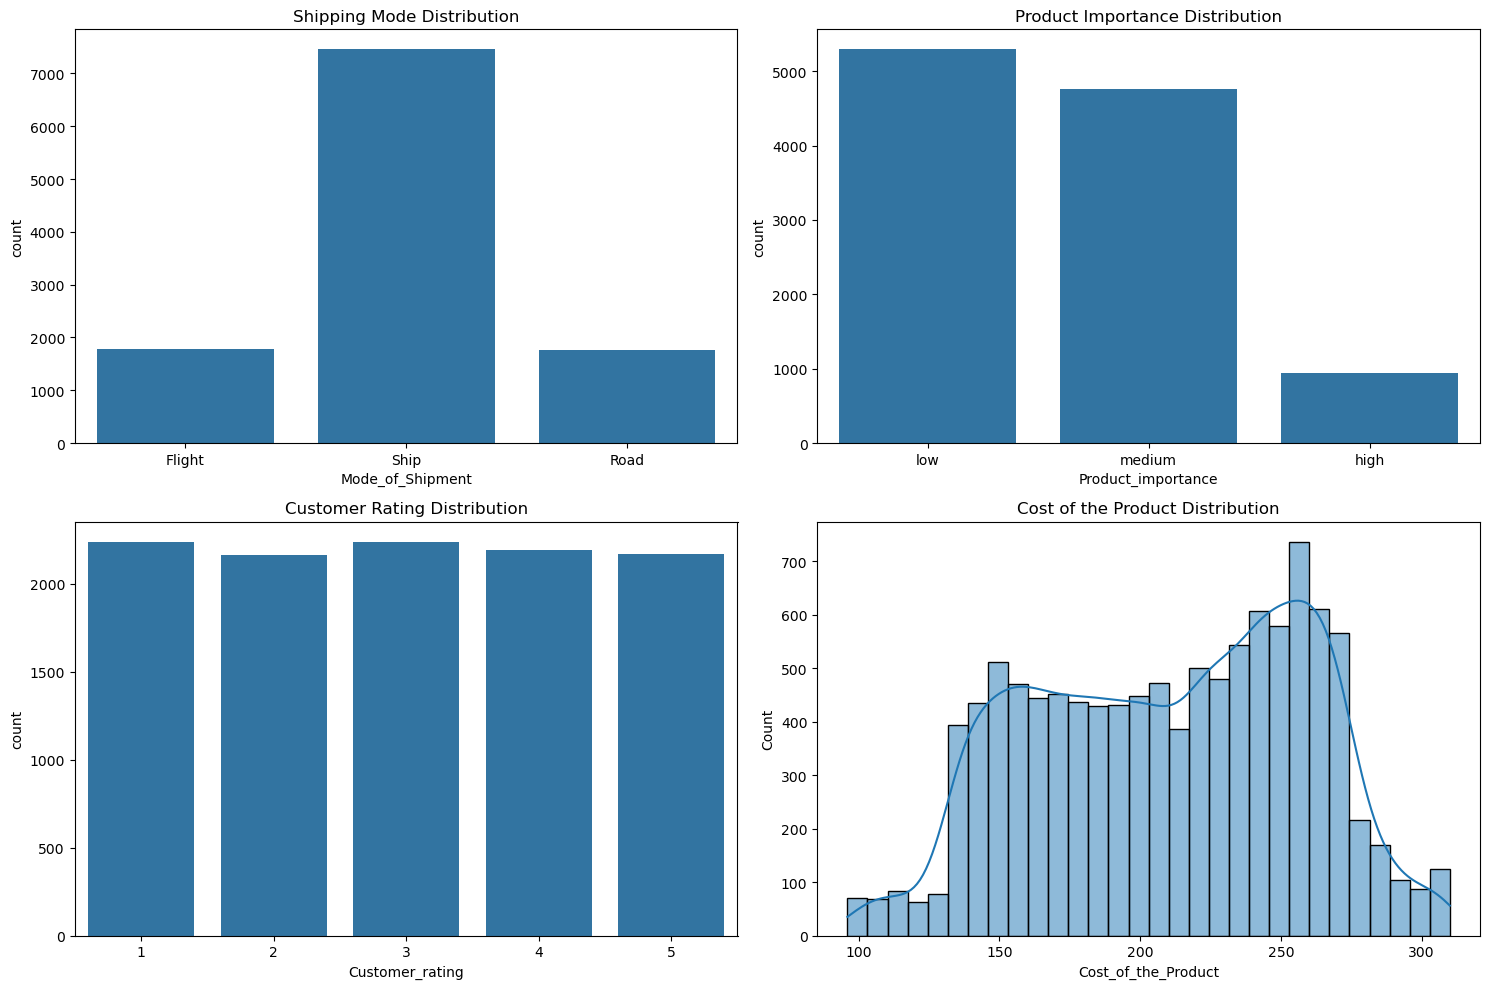

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(15, 10))


plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Mode_of_Shipment')
plt.title('Shipping Mode Distribution')


plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Product_importance')
plt.title('Product Importance Distribution')


plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Customer_rating')
plt.title('Customer Rating Distribution')


plt.subplot(2, 2, 4)
sns.histplot(df['Cost_of_the_Product'], kde=True, bins=30)
plt.title('Cost of the Product Distribution')

plt.tight_layout()
plt.show()

In [5]:

categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender'], dtype='object')


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Product_importance'] = le.fit_transform(df['Product_importance'])

In [7]:
df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment', 'Gender'], drop_first=True).astype(int)

In [8]:
df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Calls_Per_Purchase,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,1,4,2,177,3,1,44,1233,1,1,0,0,1,0,0,0,0
1,2,4,5,216,2,1,59,3088,1,1,0,0,0,1,0,0,1
2,3,2,2,183,4,1,48,3374,1,0,0,0,0,0,0,0,1
3,4,3,3,176,4,2,10,1177,1,0,1,0,0,0,0,0,1
4,5,2,2,184,3,2,46,2484,1,0,0,1,0,0,0,0,0


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Reached.on.Time_Y.N'])
y = df['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
print(X_train.shape)
print(X_test.shape)

(8799, 16)
(2200, 16)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


model = RandomForestClassifier(random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.6718181818181819


In [12]:
import pickle


with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [13]:
import joblib
joblib.dump(model, 'model.pkl')

['model.pkl']